In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
os.makedirs(
    'outputs/results',
    exist_ok=True
)

os.makedirs(
    'outputs/plots/banking',
    exist_ok=True
)

print("Folders ready.")

Folders ready.


In [4]:
results = pd.DataFrame([

    {
        'Sector':'Banking',
        'Model':'Logistic Regression',
        'Accuracy':0.7095,
        'Precision':0.3827,
        'Recall':0.6978,
        'F1':0.4943,
        'ROC_AUC':0.7670
    },

    {
        'Sector':'Banking',
        'Model':'Random Forest',
        'Accuracy':0.8215,
        'Precision':0.5492,
        'Recall':0.6855,
        'F1':0.6098,
        'ROC_AUC':0.8563
    },

    {
        'Sector':'Banking',
        'Model':'XGBoost',
        'Accuracy':0.8470,
        'Precision':0.6305,
        'Recall':0.5995,
        'F1':0.6146,
        'ROC_AUC':0.8589
    }

])

results

,Sector,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Banking,Logistic Regression,0.7095,0.3827,0.6978,0.4943,0.7670
1,Banking,Random Forest,0.8215,0.5492,0.6855,0.6098,0.8563
2,Banking,XGBoost,0.8470,0.6305,0.5995,0.6146,0.8589


In [5]:
results.to_csv(
    'outputs/results/banking_all_results.csv',
    index=False
)

print("Results saved.")

Results saved.


In [6]:
print("Banking Model Comparison")
print("="*80)

print(
    results.to_string(index=False)
)

Banking Model Comparison
 Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
Banking Logistic Regression    0.7095     0.3827  0.6978 0.4943   0.7670
Banking       Random Forest    0.8215     0.5492  0.6855 0.6098   0.8563
Banking             XGBoost    0.8470     0.6305  0.5995 0.6146   0.8589


In [7]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC_AUC'
]

print("Best model per metric")
print("-"*40)

for metric in metrics:

    best_value = results[metric].max()

    best_model = results.loc[
        results[metric].idxmax(),
        'Model'
    ]

    print(
        f"{metric}: "
        f"{best_model} "
        f"({best_value:.4f})"
    )

Best model per metric
----------------------------------------
Accuracy: XGBoost (0.8470)
Precision: XGBoost (0.6305)
Recall: Logistic Regression (0.6978)
F1: XGBoost (0.6146)
ROC_AUC: XGBoost (0.8589)


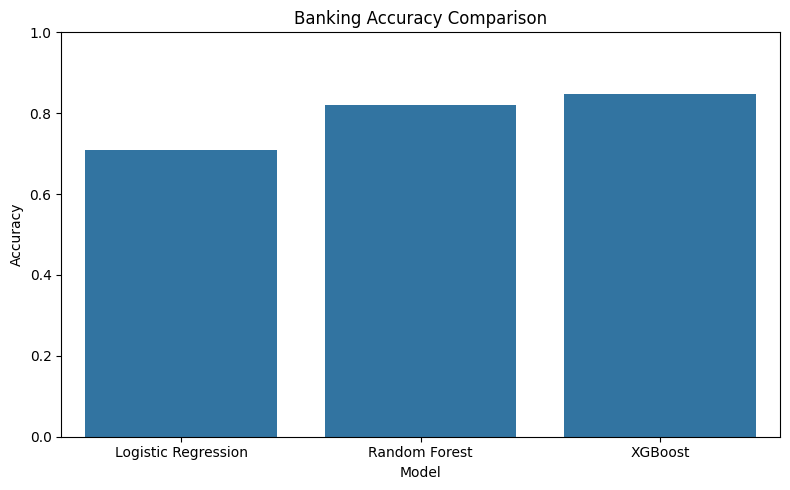

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title(
    'Banking Accuracy Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/banking/accuracy_comparison.png'
)

plt.show()

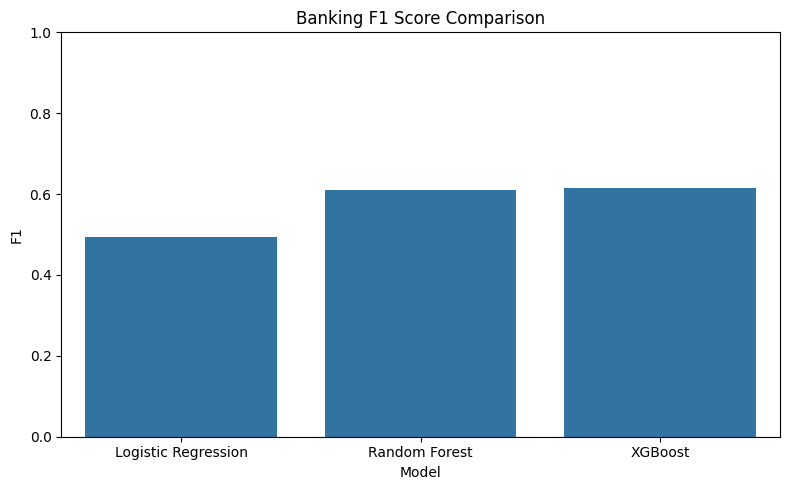

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='F1'
)

plt.title(
    'Banking F1 Score Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/banking/f1_comparison.png'
)

plt.show()

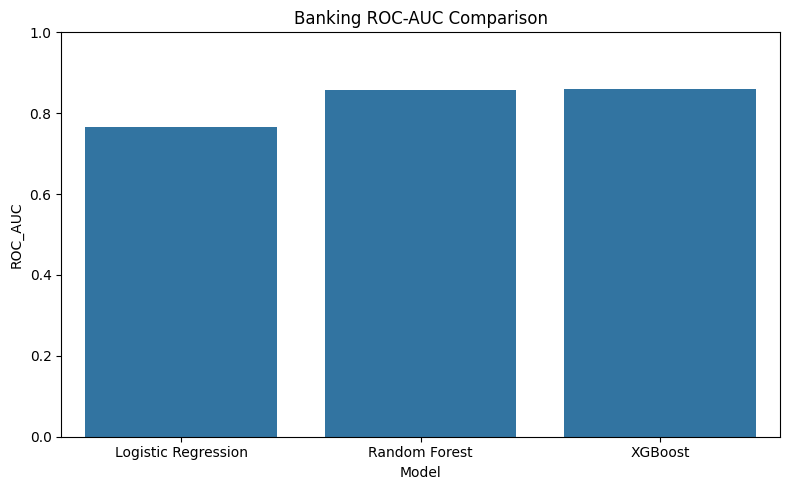

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='ROC_AUC'
)

plt.title(
    'Banking ROC-AUC Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/banking/roc_auc_comparison.png'
)

plt.show()

In [11]:
metrics_df = results.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ],
    var_name='Metric',
    value_name='Score'
)

metrics_df.head()

,Model,Metric,Score
0,Logistic Regression,Accuracy,0.7095
1,Random Forest,Accuracy,0.8215
2,XGBoost,Accuracy,0.8470
3,Logistic Regression,Precision,0.3827
4,Random Forest,Precision,0.5492


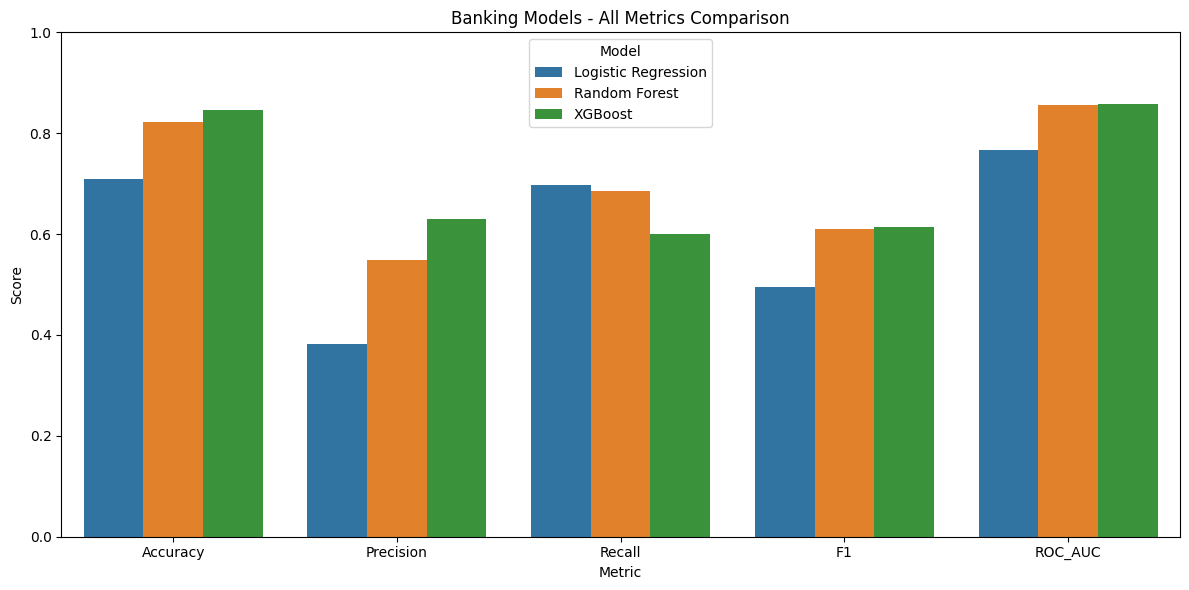

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=metrics_df,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title(
    'Banking Models - All Metrics Comparison'
)

plt.ylim(0,1)

plt.legend(
    title='Model'
)

plt.tight_layout()

plt.savefig(
    'outputs/plots/banking/all_metrics_comparison.png'
)

plt.show()

In [13]:
results['Average_Score'] = results[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
].mean(axis=1)

ranking = results.sort_values(
    by='Average_Score',
    ascending=False
)

print("Overall Ranking")
print("="*40)

print(
    ranking[
        ['Model','Average_Score']
    ]
)

Overall Ranking
                 Model  Average_Score
2              XGBoost        0.71010
1        Random Forest        0.70446
0  Logistic Regression        0.61026


In [14]:
best_model = ranking.iloc[0]['Model']

print("="*60)
print("FINAL BANKING CONCLUSION")
print("="*60)

print(
    f"Best Performing Model: {best_model}"
)

print(
    f"Average Score: "
    f"{ranking.iloc[0]['Average_Score']:.4f}"
)

print(
    "\nBanking churn is influenced by "
    "customer age, engagement, "
    "account balance and product usage."
)

print(
    "\nXGBoost achieved the strongest "
    "overall performance and is selected "
    "as the recommended banking churn model."
)

FINAL BANKING CONCLUSION
Best Performing Model: XGBoost
Average Score: 0.7101

Banking churn is influenced by customer age, engagement, account balance and product usage.

XGBoost achieved the strongest overall performance and is selected as the recommended banking churn model.
